<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/EfficientNetV2B3_Transfer_Learning_Framework_for_Multi_Class_Skin_Lesion_Classification_on_the_HAM10000_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [2]:
DATASET_DIR = "/content/drive/MyDrive/Skin Cancer MNIST HAM10000/split"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

In [3]:
IMG_SIZE = 300
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


In [7]:
base_model = tf.keras.applications.EfficientNetV2B3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False


inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype='float32'
)(x)

model = models.Model(inputs, outputs)

model.summary()

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,790,277 (52.61 MB)

 Trainable params: 5,352,857 (20.42 MB)

 Non-trainable params: 8,437,420 (32.19 MB)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7
)

checkpoint = callbacks.ModelCheckpoint(
    "best_HAM10000_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

In [10]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=callbacks_list,
    class_weight=class_weights
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 7221s 29s/step - accuracy: 0.3470 - loss: 1.9280 - val_accuracy: 0.4348 - val_loss: 1.5223 - learning_rate: 3.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2857s 11s/step - accuracy: 0.4534 - loss: 1.4507 - val_accuracy: 0.5916 - val_loss: 1.1656 - learning_rate: 3.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2890s 12s/step - accuracy: 0.5067 - loss: 1.2842 - val_accuracy: 0.5407 - val_loss: 1.2575 - learning_rate: 3.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2862s 11s/step - accuracy: 0.5532 - loss: 1.1542 - val_accuracy: 0.6041 - val_loss: 1.0686 - learning_rate: 3.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2939s 12s/step - accuracy: 0.5529 - loss: 1.1271 - val_accuracy: 0.5791 - val_loss: 1.1405 - learning_rate: 3.0000e-04
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2907s 12s/step - accuracy: 0.5785 - loss: 1.0599 - val_accuracy: 0.6485 - val_loss: 0.9164 - learning_rate: 3.0000e-04
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2960s 

In [11]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Final Accuracy:", acc * 100)
print("="*40)

63/63 ━━━━━━━━━━━━━━━━━━━━ 413s 7s/step - accuracy: 0.6485 - loss: 0.9164
Final Accuracy: 64.8527204990387


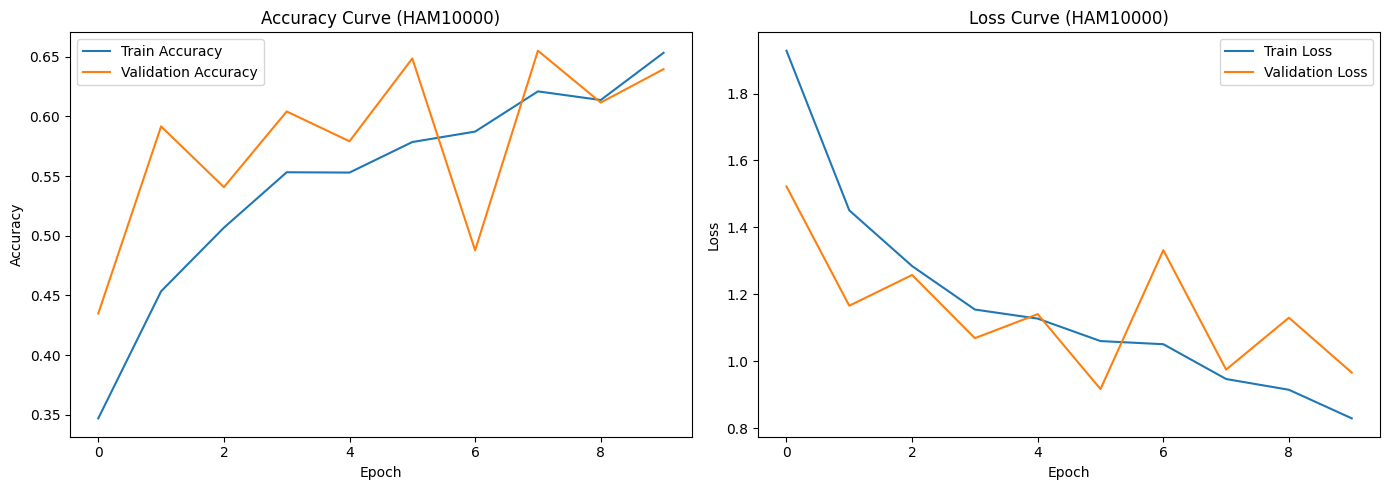

In [20]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve (HAM10000)')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve (HAM10000)')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

63/63 ━━━━━━━━━━━━━━━━━━━━ 434s 7s/step


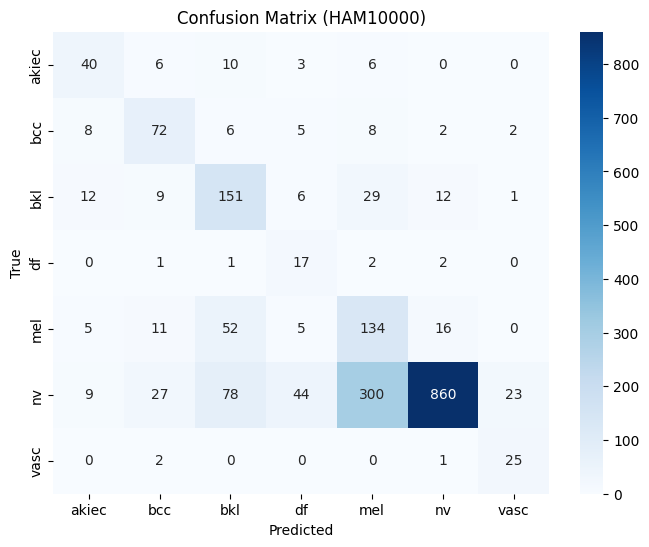

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (HAM10000)")
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.54      0.62      0.58        65
         bcc       0.56      0.70      0.62       103
         bkl       0.51      0.69      0.58       220
          df       0.21      0.74      0.33        23
         mel       0.28      0.60      0.38       223
          nv       0.96      0.64      0.77      1341
        vasc       0.49      0.89      0.63        28

    accuracy                           0.65      2003
   macro avg       0.51      0.70      0.56      2003
weighted avg       0.79      0.65      0.69      2003



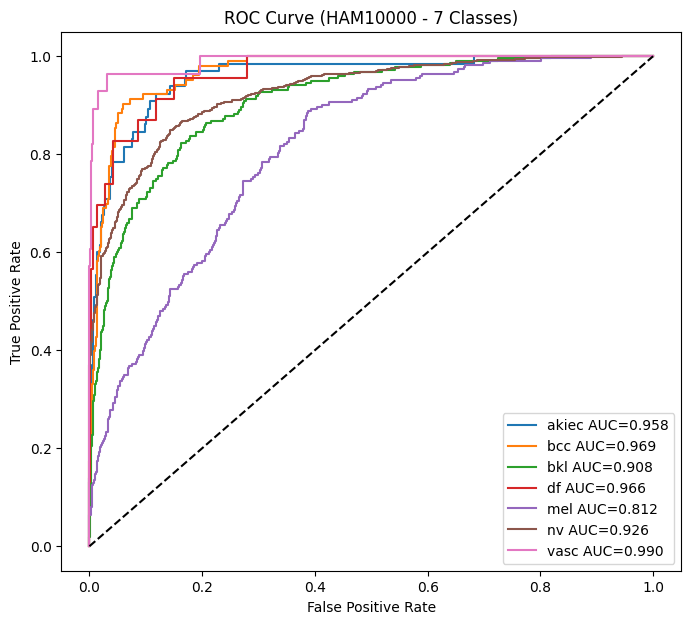

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

plt.figure(figsize=(8,7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_names[i]} AUC={roc_auc:.3f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (HAM10000 - 7 Classes)")
plt.legend()
plt.show()

In [17]:
print("\nAUC VALUES\n")

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    print(class_names[i], ":", round(roc_auc, 4))


AUC VALUES

akiec : 0.9583
bcc : 0.9689
bkl : 0.9075
df : 0.9659
mel : 0.8121
nv : 0.9257
vasc : 0.9903


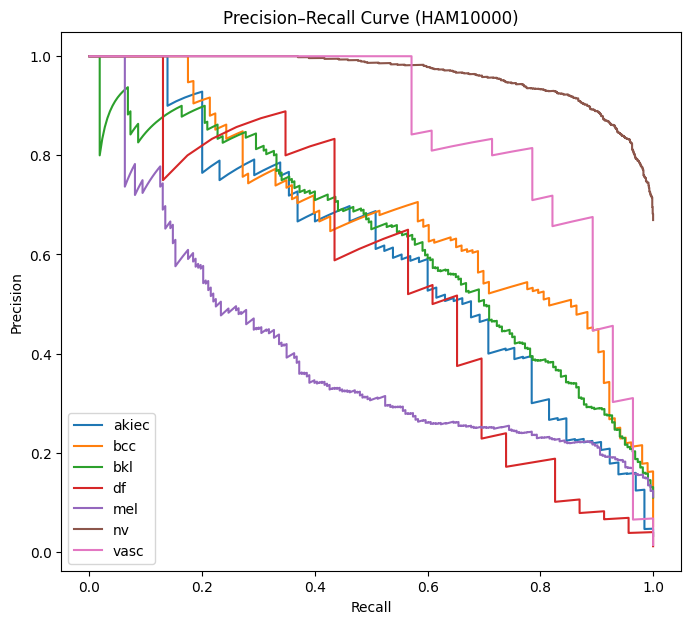

In [18]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,7))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(recall, precision, label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (HAM10000)")
plt.legend()
plt.show()

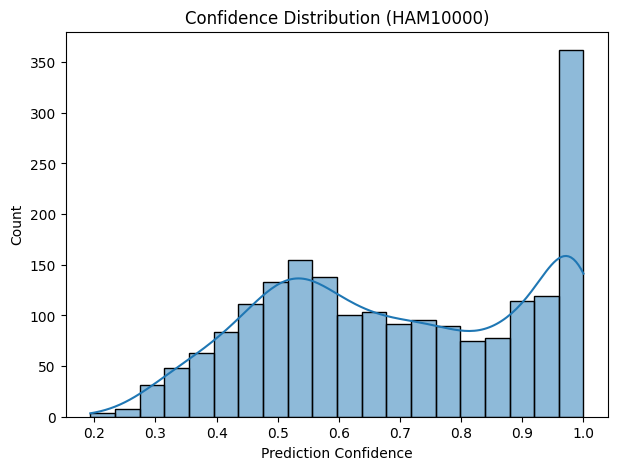

In [19]:
confidence = np.max(y_pred_prob, axis=1)

plt.figure(figsize=(7,5))
sns.histplot(confidence, bins=20, kde=True)

plt.title("Confidence Distribution (HAM10000)")
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.show()